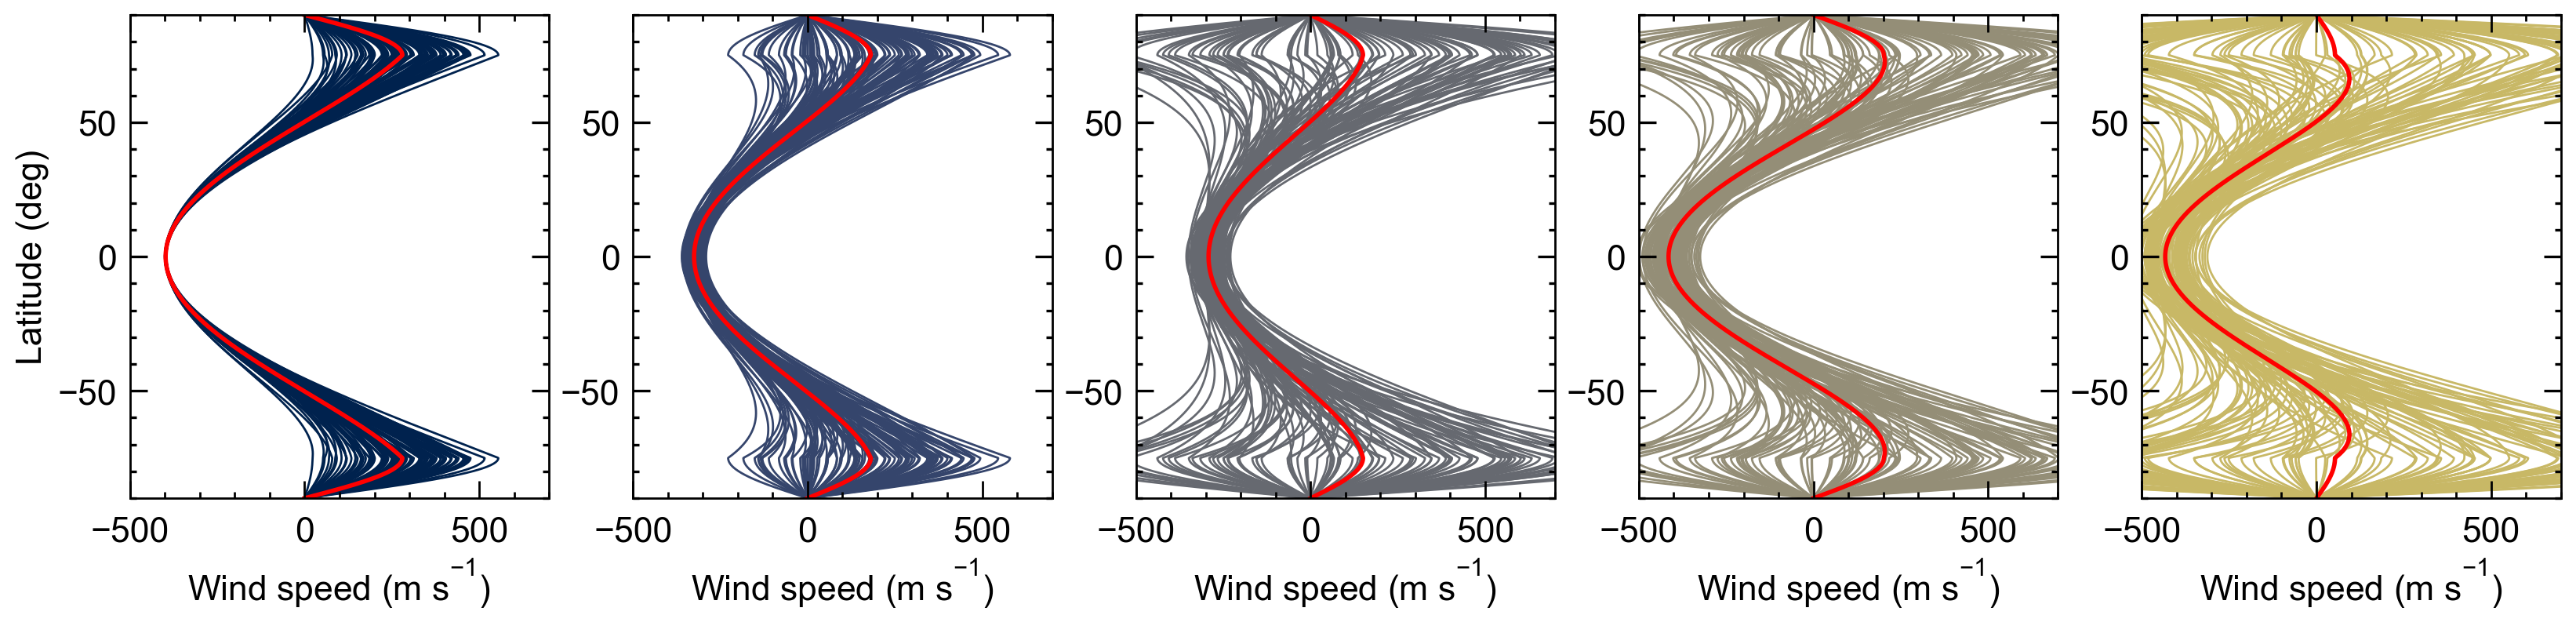

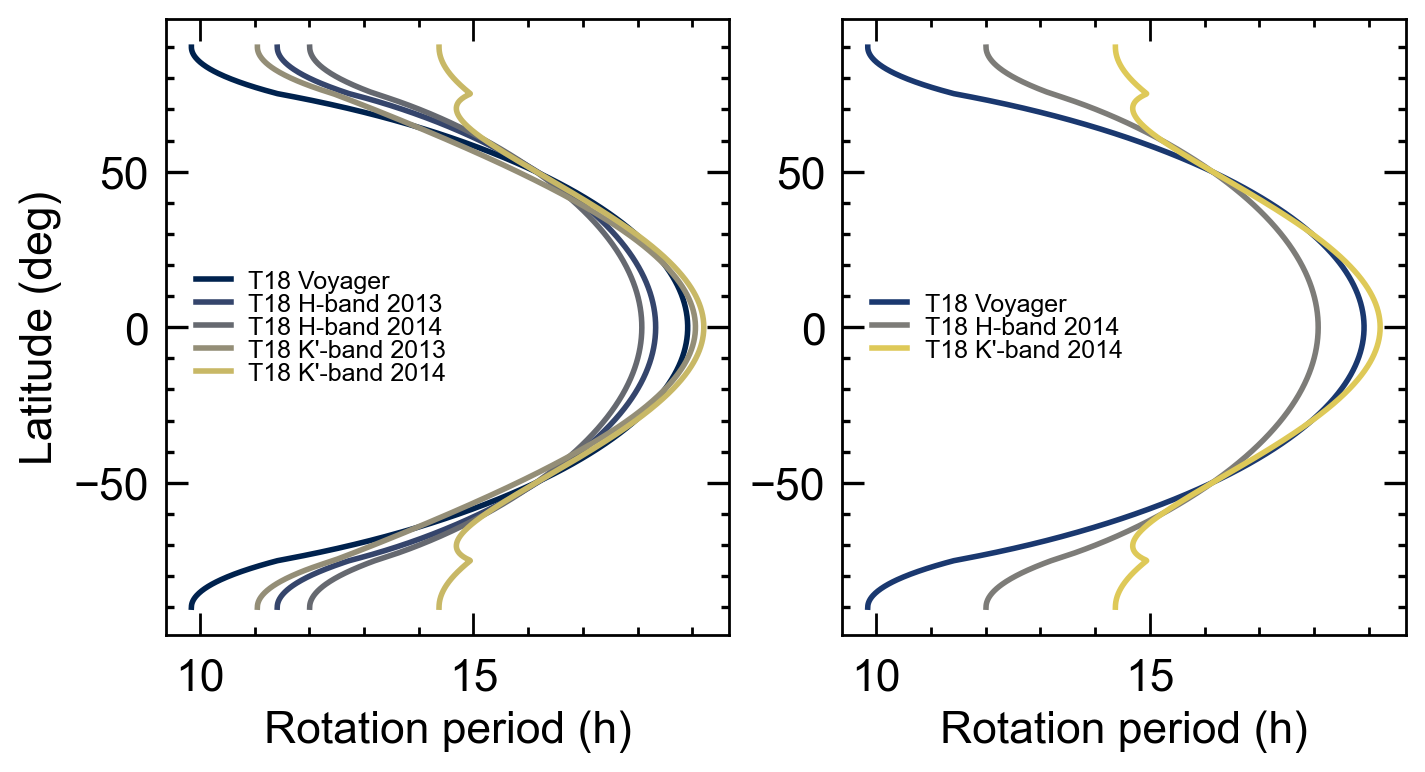

In [1]:
import matplotlib.pyplot as plt
plt.style.use(f'plots.mplstyle')
%config InlineBackend.figure_format = 'retina'

import numpy as np
from krono import const
from scipy.integrate import trapezoid
from importlib import reload

import wind_profiles; reload(wind_profiles)
import geoid; reload(geoid)

# constants for Neptune; Jacobson 2009
r_ref = 25225e5
jn = 3408.43e-6, -33.4e-6, 0. # for reference, j2 and j4 uncertainties are 4.5e-6 and 2.9e-6
gm = 6836527e15

periods = 15.11, 16.11, 17.11

# occultations, Lindal 1992
occultation_radii = {'voyager 2 egress': (-40.07, 24599.58)} # why no measurement on ingress?

# plot Neptune wind profiles to get orientated
wind_labels_all = {
    'voyager':'T18 Voyager',
    'h-band 2013':'T18 H-band 2013',
    'h-band 2014':'T18 H-band 2014',
    'k-band 2013':"T18 K'-band 2013",
    'k-band 2014':"T18 K'-band 2014",
}
wind_options = {
    'voyager':{
        'label':'T18 Voyager',
        'linestyle':'-',
        'linewidth':2.5,
        'color':plt.get_cmap('cividis')(1. / 8),
    },
    'h-band 2014':{
        'label':'T18 H-band 2014',
        'linestyle':'--',
        'linewidth':1,
        'color':plt.get_cmap('cividis')(0.5),
    },
    'k-band 2014':{
        'label':"T18 K'-band 2014",
        'linestyle':'-.',
        'linewidth':1,
        'color':plt.get_cmap('cividis')(7. / 8),
    },
}

ph = wind_profiles._phi_grid
fig, ax = plt.subplots(1, 5, figsize=(20, 4))
for iwind, (wind_option, wind_label) in enumerate(wind_labels_all.items()):
    color = plt.get_cmap('cividis')(1. * iwind / len(list(wind_labels_all)))

    ax[iwind].plot(wind_profiles.neptune_wind_profile_tollefson2018(ph, option=wind_option, pole_attenuation='cosine', randomize=False) * 1e-2, ph * 180 / np.pi, 'r-', zorder=1)
    np.random.seed(2025)
    for i in range(100):
        ax[iwind].plot(wind_profiles.neptune_wind_profile_tollefson2018(ph, option=wind_option, pole_attenuation='cosine', randomize=True) * 1e-2, ph * 180 / np.pi, color=color, lw=1, zorder=-1)

[z.set_xlim(-500, 700) for z in ax]
[z.set_ylim(-90, 90) for z in ax]
[z.set_xlabel(r'Wind speed (m s$^{-1}$)') for z in ax]
ax[0].set_ylabel('Latitude (deg)')

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for iwind, (wind_option, wind_label) in enumerate(wind_labels_all.items()): # all five Tollefson+2018 profiles and old color scheme
    color = plt.get_cmap('cividis')(1. * iwind / len(list(wind_labels_all)))
    omega = wind_profiles.neptune_omega_tot_interpolant(option=wind_option, pole_attenuation='cosine', randomize=False)
    ax[0].plot(np.pi * 2. / (omega(ph) * 3600), ph * 180 / np.pi, color=color, label=wind_label)

for iwind, (wind_option, spec) in enumerate(wind_options.items()): # pare down to three Tollefson+2018 profiles with more discernable colors
    omega = wind_profiles.neptune_omega_tot_interpolant(option=wind_option, pole_attenuation='cosine', randomize=False)
    ax[1].plot(np.pi * 2. / (omega(ph) * 3600), ph * 180 / np.pi, color=spec['color'], label=spec['label'])

ax[0].set_xlabel('Rotation period (h)')
ax[1].set_xlabel('Rotation period (h)')
ax[0].set_ylabel('Latitude (deg)')
ax[0].legend(fontsize=9)
ax[1].legend(fontsize=9)


    period      r_pol r_eq_geoid       r_eq     h_mean
     15.11    24285.3    24778.4    24760.6      16.44
     16.11    24285.3    24733.3    24760.6      38.50
     17.11    24285.3    24696.3    24760.6      56.67


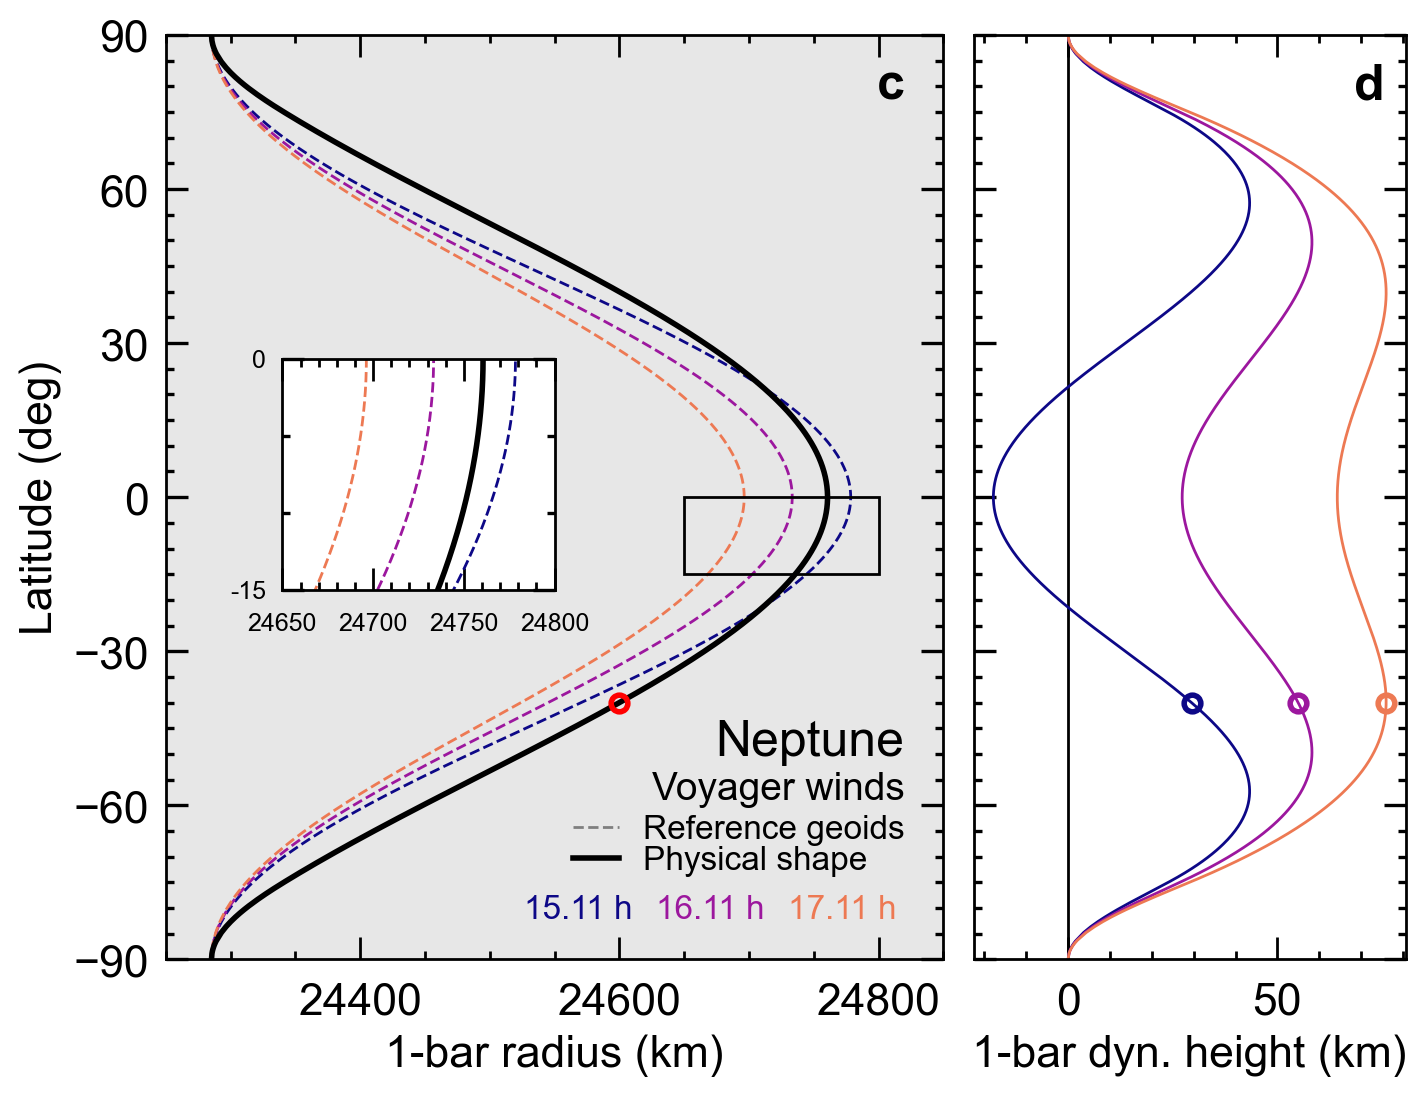

In [2]:
# main shape model plot for paper
def shape_plot(xlim=(24250, 24850), skip_inset_eq=False, inset_xlim=(24650, 24800), inset_ylim=(-15, 0), inset_loc=[0.15, 0.4, 0.35, 0.25]):    
    from matplotlib.patches import Rectangle
    fig, ax = plt.subplots(1, 2, figsize=(8, 6), gridspec_kw={'width_ratios':(9, 5), 'wspace':0.05})
    if not skip_inset_eq: # inset near equator
        ax_inset_eq = ax[0].inset_axes(inset_loc, xlim=inset_xlim, ylim=inset_ylim, xticklabels=[], yticklabels=[])
        ax[0].add_artist(Rectangle((inset_xlim[0], inset_ylim[0]), inset_xlim[1]-inset_xlim[0], inset_ylim[1]-inset_ylim[0], facecolor='none', edgecolor='k', lw=1, zorder=5))
        num_minor_ticks = (inset_xlim[1] - inset_xlim[0]) // 50 + 1
        if num_minor_ticks <=3: num_minor_ticks += 2
        xticks = np.linspace(inset_xlim[0], inset_xlim[1], num_minor_ticks)
        # print(inset_xlim, xticks, num_minor_ticks)
        ax_inset_eq.set_xticks(xticks, minor=True)
        ax_inset_eq.set_xticks([inset_xlim[0], inset_xlim[1]], [inset_xlim[0], inset_xlim[1]], minor=False, fontsize=9)
        ax_inset_eq.set_yticks(inset_ylim[0] + 5 * np.array([0, 1, 2, 3]), minor=True)
        ax_inset_eq.set_yticks(inset_ylim, inset_ylim, minor=False, fontsize=9)
        ax_inset_eq.set_xlim(*inset_xlim)

    yl = -90, 90 # ax[1].get_ylim()
    ax[1].vlines(0, *yl, color='k', linewidth=1, zorder=-1)
    for z in ax:
        z.set_yticks(np.linspace(-90, 90, 7), minor=False)
        z.set_yticks(np.linspace(-90, 90, 37), minor=True)
        z.set_ylim(*yl)
    ax[1].tick_params(labelleft=False)
    ax[0].set_ylabel('Latitude (deg)')
    # ax[0].set_xlabel('100-mbar radius (km)')
    # ax[1].set_xlabel('100-mbar dyn. height (km)')
    ax[0].set_xlabel('1-bar radius (km)')
    ax[1].set_xlabel('1-bar dyn. height (km)')
    ax[0].set_facecolor('#e7e7e7')
    ax[0].set_xlim(*xlim)

    if skip_inset_eq:
        return ax
    else:
        return ax, ax_inset_eq

ax, ax_inset = shape_plot()
ax_inset.set_xticks(24650 + 10 * np.arange(15), minor=True)
ax_inset.set_xticks(24650 + 50 * np.arange(4), 24650 + 50 * np.arange(4), minor=False, fontsize=9)

# inset axis highlights region near the occultation point instead:
# ax, ax_inset = shape_plot(inset_xlim=(24500, 24650), inset_ylim=(-45, -30))
# ax_inset.set_xticks(24500 + 10 * np.arange(15), minor=True)
# ax_inset.set_xticks([24500, 24550, 24600, 24650], [24500, 24550, 24600, 24650], minor=False, fontsize=9)

reload(geoid)
print(f"{'period':>10} {'r_pol':>10} {'r_eq_geoid':>10} {'r_eq':>10} {'h_mean':>10}")

omega = wind_profiles.neptune_omega_tot_interpolant(option='voyager', pole_attenuation='cosine', randomize=False)

r_pol = 25000e5
for i in range(10):
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation

    # compare to data and adjust r_pol
    latitude, radius = occultation_radii['voyager 2 egress']
    error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
    if abs(error_km) < 0.001: break
    r_pol += 1e5 * error_km
else:
    raise RuntimeError('failed in iterations to fit occultations')

# ax, ax_inset_eq, ax_inset_pol = plot(g, color='k', suppress_legend=True, skip_inset_pol=False, width_ratios=(9, 5), xlim_inset_pol=(24970, 24980))
ax[0].plot(1e-5 * g.r, g.lat, 'k-')
ax_inset.plot(1e-5 * g.r, g.lat, 'k-')
for occ, (latitude, radius) in occultation_radii.items():
    ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=2)
    ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=2)

# reference geoids depend on rigid rotation; loop through them now
for ip, p_rot_h in enumerate(periods):
    
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]
    g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))
    r_eq_ref = g_ref.r[len(g.mu) // 2]
    
    color = plt.get_cmap('plasma')(1. * (ip) / 3)

    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1, zorder=0)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[1].plot(np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1]), latitude, 'o', color=color, mfc='none', mew=2)

    ax[0].text(0.6 + 0.17 * ip, 0.07, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='right', va='top', transform=ax[0].transAxes)
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq_ref:10.1f} {1e-5*r_eq:10.1f} {1e-5 * h_mean:10.2f}')


ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoids')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape') 
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.057), fontsize=12)
ax[0].text(0.95, 0.21, 'Neptune', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.165, 'Voyager winds', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)

for iax, c in enumerate('cd'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

import copy
g_baseline = copy.deepcopy(g) # store main shape model to write to disk later

plt.savefig('figures/neptune_optimize_rpol.pdf')

    # period      r_pol r_eq_geoid       r_eq     h_mean
    #  15.11    24285.3    24778.4    24760.6      16.44
    #  16.11    24285.3    24733.3    24760.6      38.50
    #  17.11    24285.3    24696.3    24760.6      56.67


                          wind     period      r_pol       r_eq     h_mean
                       voyager      16.11    24285.3    24760.6      38.50
                   h-band 2014      16.11    24311.2    24768.2      18.18
                   k-band 2014      16.11    24325.1    24759.9       4.05


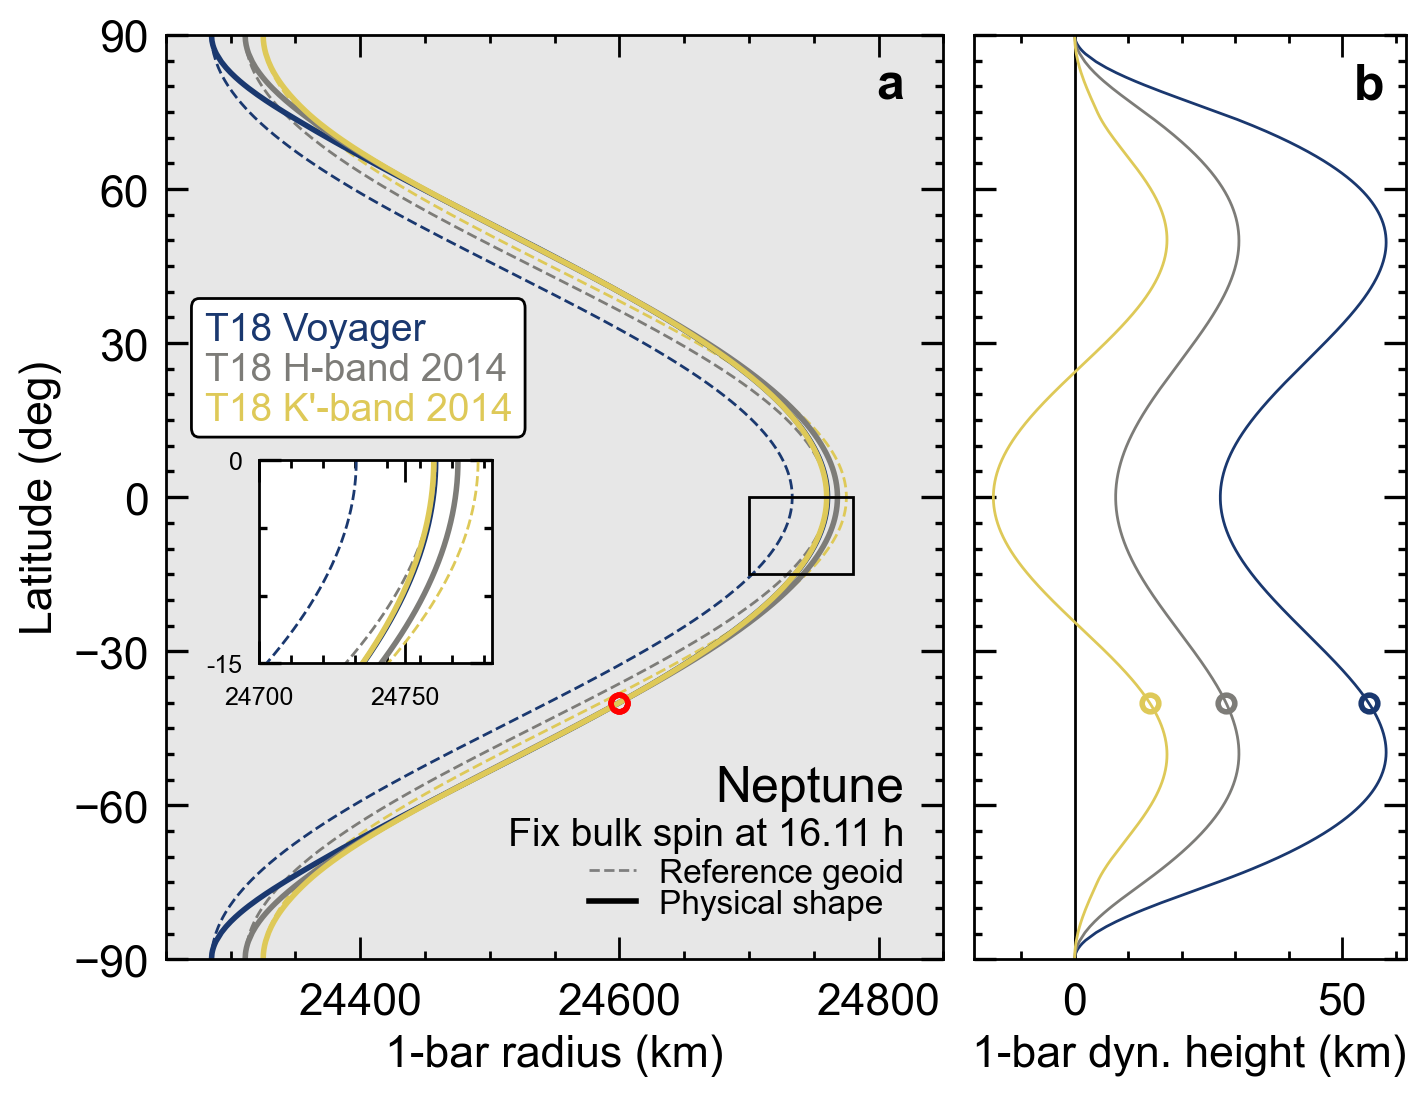

In [3]:
# same but fix background rotation and vary assumed wind profile

ax, ax_inset = shape_plot(inset_xlim=(24700, 24780), inset_loc=[0.12, 0.32, 0.3, 0.22])
ax_inset.set_xticks(24700 + 11 * np.arange(8), minor=True)
ax_inset.set_xticks([24700, 24750], [24700, 24750], minor=False, fontsize=9)

# inset axis highlights region near occultation instead?
# ax, ax_inset = shape_plot(inset_xlim=(24500, 24650), inset_ylim=(-45, -30), inset_loc=[0.12, 0.32, 0.3, 0.22])
# ax_inset.set_xticks(24500 + 10 * np.arange(15), minor=True)
# ax_inset.set_xticks([24500, 24550, 24600, 24650], [24500, 24550, 24600, 24650], minor=False, fontsize=9)

reload(geoid)
print(f"{'wind':>30} {'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")

p_rot_h = 16.11
# for iwind, (wind_option, wind_label) in enumerate(wind_labels.items()):
for iwind, (wind_option, spec) in enumerate(wind_options.items()):
    
    omega = wind_profiles.neptune_omega_tot_interpolant(option=wind_option, pole_attenuation='cosine', randomize=False)
    # color = plt.get_cmap('cividis')(1. * iwind / len(list(wind_labels)))
    color = spec['color']

    # fit isobaric shape to occultation
    r_pol = 25000e5
    for i in range(10):
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation

        # compare to data and adjust r_pol
        latitude, radius = occultation_radii['voyager 2 egress']
        error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
        if abs(error_km) < 0.001: break
        r_pol += 1e5 * error_km
    else:
        raise RuntimeError('failed in iterations to fit occultations')

    # ax, ax_inset_eq, ax_inset_pol = plot(g, color='k', suppress_legend=True, skip_inset_pol=False, width_ratios=(9, 5), xlim_inset_pol=(24970, 24980))
    ax[0].plot(1e-5 * g.r, g.lat, color=color)
    ax_inset.plot(1e-5 * g.r, g.lat, color=color)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=2)
        ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=2)

    # create a rigidly rotating reference geoid for comparison
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]
    g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))
    
    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1, zorder=0)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[1].plot(np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1]), latitude, 'o', color=color, mfc='none', mew=2)

    # ax[0].text(0.53, 0.95 - 0.04 * iwind, wind_label, color=color, fontsize=12, ha='left', va='top', transform=ax[0].transAxes)
    ax[0].text(0.05, 0.7 - 0.043 * iwind, spec['label'], color=color, fontsize=14, ha='left', va='top', transform=ax[0].transAxes)
    print(f'{wind_option:>30} {p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * h_mean:10.2f}')

from matplotlib.patches import Rectangle, FancyBboxPatch
ax[0].add_artist(FancyBboxPatch((0.043, 0.575), 0.409, 0.13, facecolor='w', edgecolor='k', zorder=0, transform=ax[0].transAxes, boxstyle='Round, pad=0.01'))

ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoid')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape') 
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.01), fontsize=12)
ax[0].text(0.95, 0.16, 'Neptune', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.115, 'Fix bulk spin at 16.11 h', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)

for iax, c in enumerate('ab'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

plt.savefig('figures/neptune_optimize_rpol_vary_wind.pdf')


In [4]:
# what planetary rotation period minimizes neptune's dynamical heights?

reload(geoid)
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")

omega = wind_profiles.neptune_omega_tot_interpolant(option='voyager', pole_attenuation='cosine', randomize=False) # the answer will depend on which wind option, though

r_pol = 25000e5
for i in range(10):
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation

    # compare to data and adjust r_pol
    latitude, radius = occultation_radii['voyager 2 egress']
    error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
    if abs(error_km) < 0.001: break
    r_pol += 1e5 * error_km
else:
    raise RuntimeError('failed in iterations to fit occultations')

r_eq = g.r[len(g.mu) // 2]

# iterate to find the period that minimizes the dynamical height
def zero_me(p_rot_h):
    g_ref = geoid.geoid(g.r[0], jn, r_ref, gm, omega=np.pi*2/(p_rot_h[0]*3600))
    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)
    print(f'{p_rot_h[0]:10.2f} {1e-5 * r_pol:10.2f} {1e-5 * r_eq:10.2f} {1e-5 * h_mean:10.2f}')
    return h_mean

from scipy.optimize import root
sol = root(zero_me, 16.11, tol=1e-10)
print(sol)
print(sol.x[0]) # 14.48 h


    period      r_pol       r_eq     h_mean
     16.11   24285.27   24760.55      38.50
     16.11   24285.27   24760.55      38.50
     16.11   24285.27   24760.55      38.50
     16.11   24285.27   24760.55      38.50
     14.18   24285.27   24760.55      -8.63
     14.53   24285.27   24760.55       1.49
     14.48   24285.27   24760.55       0.05
     14.48   24285.27   24760.55      -0.00
     14.48   24285.27   24760.55       0.00
     14.48   24285.27   24760.55      -0.00
     14.48   24285.27   24760.55       0.00
     14.48   24285.27   24760.55       0.00
 message: The solution converged.
 success: True
  status: 1
     fun: -2.221928702460395e-07
       x: [ 1.448e+01]
  method: hybr
    nfev: 12
    fjac: [[-1.000e+00]]
       r: [-1.464e+07]
     qtf: [ 2.222e-07]
14.479082142048139


In [5]:
# same exercise with split-style method

reload(geoid)
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")

omega = wind_profiles.neptune_omega_tot_interpolant(option='voyager', pole_attenuation='cosine', randomize=False)

def zero_me(p_rot_h):
    r_pol = 25000e5
    for i in range(10):
        g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=np.pi*2/(p_rot_h[0]*3600), omega=omega)

        # compare to data and adjust r_pol
        latitude, radius = occultation_radii['voyager 2 egress']
        error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
        if abs(error_km) < 0.001: break
        r_pol += 1e5 * error_km
    else:
        raise RuntimeError('failed in iterations to fit occultations')

    h_mean = -1. / 180 * trapezoid(g.h, x=g.lat)
    print(p_rot_h[0], h_mean)
    return 1e-5 * h_mean

from scipy.optimize import root
sol = root(zero_me, 16.11, tol=1e-10)
print(sol)
print(sol.x[0]) # 14.49 h


    period      r_pol       r_eq     h_mean
16.11 3831772.5266142464
16.11 3831772.5266142464
16.11 3831772.5266142464
16.110000240057705 3831773.004144813
14.183743146616811 -884195.9091381817
14.544896630342166 156287.1184230643
14.490649097432202 5365.460316188137
14.488720527412958 -33.83325930544072
14.48873261229196 0.0072740818063418075
14.488732609694294 1.1341439353095162e-08
14.48873260969429 8.443991343180338e-09
14.488732609694278 -3.0878517362806535e-08
14.488732609694289 2.06960572136773e-09
 message: The solution converged.
 success: True
  status: 1
     fun: 2.0696057213677304e-14
       x: [ 1.449e+01]
  method: hybr
    nfev: 13
    fjac: [[-1.000e+00]]
       r: [-3.331e+01]
     qtf: [-8.444e-14]
14.488732609694289


In [6]:
# again for the default method, looping through the different profiles provided by Tollefson

reload(geoid)
# print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")

def zero_me(p_rot_h, wind_option):
    omega = wind_profiles.neptune_omega_tot_interpolant(option=wind_option, pole_attenuation='cosine', randomize=False) # the answer will depend on which wind option, though

    r_pol = 25000e5
    for i in range(10):
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation

        # compare to data and adjust r_pol
        latitude, radius = occultation_radii['voyager 2 egress']
        error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
        if abs(error_km) < 0.001: break
        r_pol += 1e5 * error_km
    else:
        raise RuntimeError('failed in iterations to fit occultations')

    r_eq = g.r[len(g.mu) // 2]

    g_ref = geoid.geoid(g.r[0], jn, r_ref, gm, omega=np.pi*2/(p_rot_h[0]*3600))
    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)
    # print(f'{p_rot_h[0]:10.2f} {1e-5 * r_pol:10.2f} {1e-5 * r_eq:10.2f} {1e-5 * h_mean:10.2f}')
    return h_mean

# iterate to find the period that minimizes the dynamical height
from scipy.optimize import root
for wind_option, spec in wind_options.items():
    sol = root(zero_me, 16.11, tol=1e-10, args=(wind_option,))
    print(f'{wind_option:>12} {sol.x[0]:.2f}')


     voyager 14.48
 h-band 2014 15.28
 k-band 2014 15.91


In [7]:
# compare equatorial height with baseline method vs. split method. difference ~0.5 km

g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)
print(1e-5 * g.r[len(g.mu) // 2])
g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=np.pi * 2 / 16.11 / 3600, omega=omega)
print(1e-5 * g.r[len(g.mu) // 2])

24760.554491825253
24761.056317385228


In [8]:
# the models below are for uncertainty quantification, doing some tens of thousands of models with input parameters (wind profiles, occultation radii, gravity moments) drawn from statistical distributions.
# in contrast with Uranus, these Neptune runs are quite fast (each 10,000-model run takes less than a minute) because we use the faster split calculation.
# we avoided the split calculation for Uranus because it appears to be less accurate, but the <1 km differences are of little importance for Neptune where the wind-related uncertainty on the shape can be so much larger (up to ~100 km).
# here, if we've already run the below cells and saved the bulky (2 GB) pickle, we can load that instead of repeating the runs:

if False:
    import dill as pickle
    with open('models/geoid_objects/neptune.pkl', 'rb') as fw:
        neptune_models = pickle.load(fw)
    models_vary_wind = neptune_models['vary_wind']
    models_vary_ro = neptune_models['vary_ro']
    models_vary_jn = neptune_models['vary_jn']

# then skip the cells that would overwrite models_vary_wind, etc. these cells are the ones with with functions like solve_one(), etc. 
# can run plotting cells directly.

In [9]:
''' quantifying uncertainties in the shape as a function of those in occultation radii, gravity field, rotation profile '''

reload(geoid)
reload(wind_profiles)
np.random.seed(2025)

# how much scatter in neptunes's polar radius as a function of the uncertain wind profile?
def solve_one(wind_option, randomize=False):
    omega = wind_profiles.neptune_omega_tot_interpolant(option=wind_option, pole_attenuation='cosine', randomize=randomize)

    r_pol = 25000e5
    for i in range(50):
        # g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

        # do the faster split calculation since we are running many models -- factor of 10 faster.
        # for the large spread we get out for Neptune, the ≤ 1 km offset with respect to the full model is not important.
        g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=np.pi*2/(16.11 * 3600), omega=omega)

        # compare to data and adjust r_pol
        latitude, radius = occultation_radii['voyager 2 egress']
        error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
        if abs(error_km) < 0.001: break
        r_pol += 1e5 * error_km
    else:
        raise RuntimeError('failed in iterations to fit occultations')

    return g

from tqdm import tqdm
models_vary_wind = {}

nmodels = 10000
# for wind_option, label in wind_labels_all.items():
for wind_option, spec in wind_options.items():
    models_vary_wind[wind_option] = {}
    for i in tqdm(np.arange(nmodels)):
        models_vary_wind[wind_option][i] = solve_one(wind_option, randomize=True)

100%|██████████| 10000/10000 [00:43<00:00, 230.06it/s]


voyager: pole: $24284.7\pm32.0$ km
voyager: equator: $24761.8\pm1.3$ km
h-band 2014: pole: $24291.4\pm106.8$ km
h-band 2014: equator: $24769.5\pm5.6$ km
k-band 2014: pole: $24268.0\pm171.3$ km
k-band 2014: equator: $24761.3\pm9.3$ km


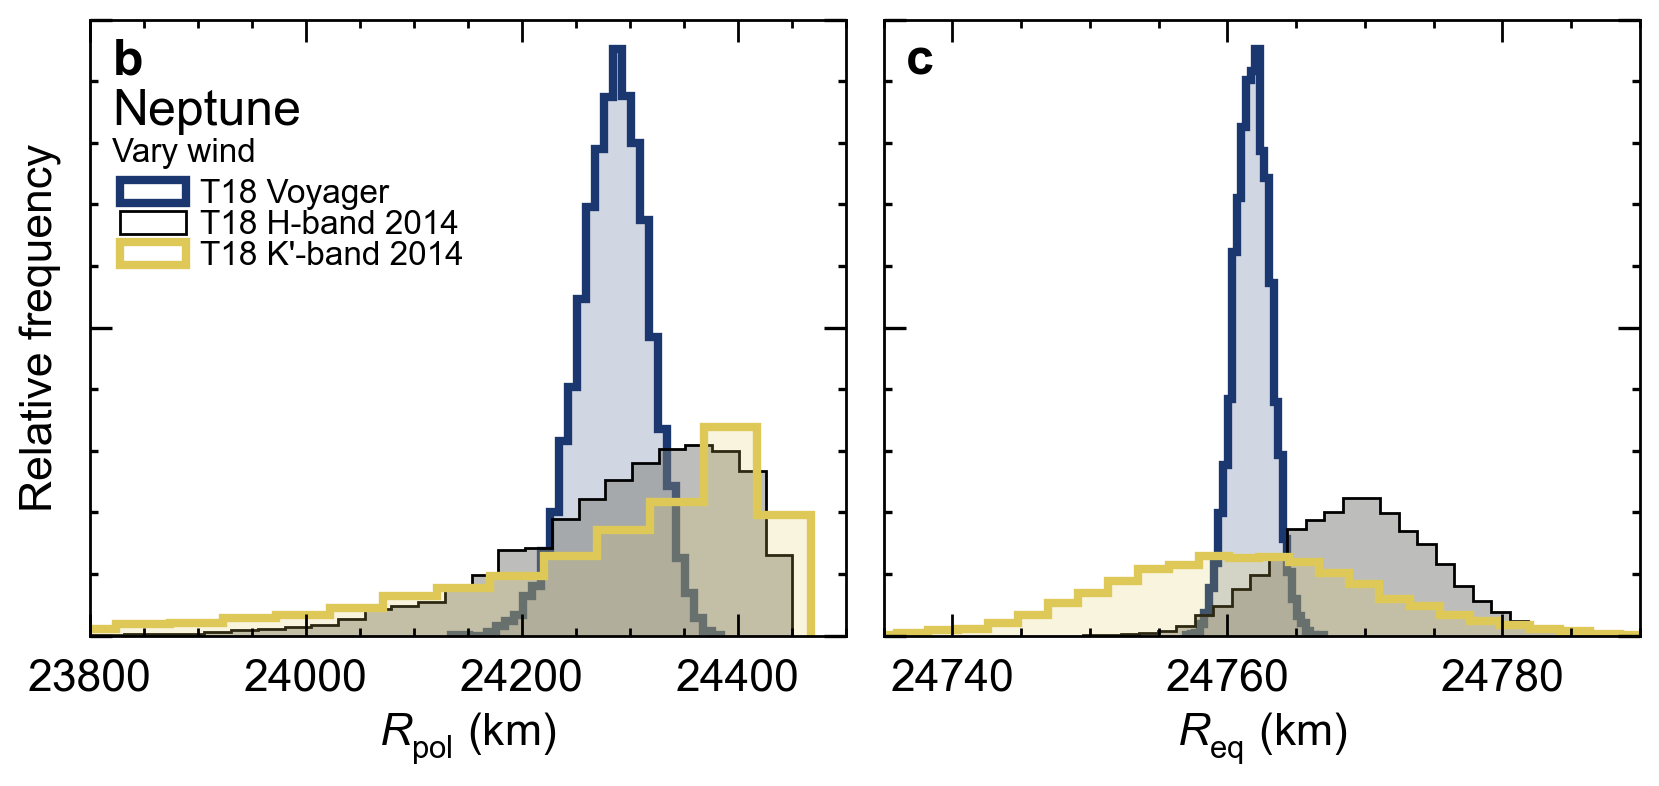

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'wspace':0.05})
for iwind, (wind_option, spec) in enumerate(wind_options.items()):
    color = spec['color']
    rp = np.array([g.r[0] for seed, g in models_vary_wind[wind_option].items()])
    re = np.array([g.r[len(g.mu) // 2] for seed, g in models_vary_wind[wind_option].items()])
    if iwind == 1:
        ax[0].hist(1e-5 * rp, alpha=0.5, histtype='stepfilled', density=True, color=color, bins=30, zorder=0)
        ax[0].hist(1e-5 * rp, histtype='step', density=True, color='k', bins=30, lw=1, label=spec['label'], zorder=0)
        ax[1].hist(1e-5 * re, alpha=0.5, histtype='stepfilled', density=True, color=color, bins=30, zorder=0)
        ax[1].hist(1e-5 * re, histtype='step', density=True, color='k', bins=30, lw=1, label=spec['label'], zorder=0)

    else:
        ax[0].hist(1e-5 * rp, alpha=0.2, histtype='stepfilled', density=True, color=color, bins=30, zorder=0)
        ax[0].hist(1e-5 * rp, histtype='step', density=True, color=color, bins=30, lw=3, label=spec['label'], zorder=0)
        ax[1].hist(1e-5 * re, alpha=0.2, histtype='stepfilled', density=True, color=color, bins=30, zorder=0)
        ax[1].hist(1e-5 * re, histtype='step', density=True, color=color, bins=30, lw=3, label=spec['label'], zorder=0)
    print(rf'{wind_option}: pole: ${np.mean(rp*1e-5):.1f}\pm{np.std(rp*1e-5):.1f}$ km')
    print(rf'{wind_option}: equator: ${np.mean(re*1e-5):.1f}\pm{np.std(re*1e-5):.1f}$ km')

for z in ax:
    yl = z.get_ylim()
    z.set_yticks([0, yl[1] / 2, yl[1]], minor=False)
    z.set_yticks(np.linspace(0, yl[1], 11), minor=True)
    z.set_ylim(*yl)

ax[0].legend(fontsize=12, loc=2, bbox_to_anchor=(0, 0.79))

ax[0].set_xlabel(r'$R_{\rm pol}$ (km)')
ax[1].set_xlabel(r'$R_{\rm eq}$ (km)')
ax[0].set_ylabel(r'Relative frequency')
# plt.gca().yaxis.set_ticks([0, yl[1]/2, yl[1]], minor=False)
[z.tick_params(labelleft=False) for z in ax]
ax[0].set_xlim(23800, 24500)
ax[1].set_xlim(24735, 24790)
ax[0].text(0.03, 0.83, 'Neptune', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.03, 0.77, 'Vary wind', fontsize=12, transform=ax[0].transAxes)
for iax, c in enumerate('bc'):
    ax[iax].text(0.03, 0.97, c, weight='bold', fontsize=18, ha='left', va='top', transform=ax[iax].transAxes)

plt.savefig('figures/neptune_radii_vary_wind.pdf')

In [11]:
''' quantifying uncertainties in the shape as a function of those in occultation radii, gravity field, rotation profile '''

reload(geoid)
reload(wind_profiles)
from scipy.stats import norm
np.random.seed(2025)

omega_interpolants = {}
for wind_option in list(wind_options):
    omega_interpolants[wind_option] = wind_profiles.neptune_omega_tot_interpolant(option=wind_option, pole_attenuation='cosine')

latitude, radius_centroid = occultation_radii['voyager 2 egress']

def solve_one_vary_ro(wind_option):

    omega = omega_interpolants[wind_option]
    radius = norm(loc=radius_centroid, scale=5.).rvs()

    r_pol = 25000e5
    for i in range(50):
        # g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

        # do the faster split calculation since we are running many models -- factor of 10 faster.
        # for the large spread we get out for Neptune, the ≤ 1 km offset with respect to the full model is not important.
        g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=np.pi*2/(16.11 * 3600), omega=omega)

        # compare to data and adjust r_pol
        error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
        if abs(error_km) < 0.001: break
        r_pol += 1e5 * error_km
    else:
        raise RuntimeError('failed in iterations to fit occultations')

    return g

from tqdm import tqdm
models_vary_ro = {}
nmodels = 10000
# for wind_option, label in wind_labels_all.items():
for wind_option, spec in wind_options.items():
    models_vary_ro[wind_option] = {}
    for i in tqdm(np.arange(nmodels)):
        models_vary_ro[wind_option][i] = solve_one_vary_ro(wind_option)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:31<00:00, 321.94it/s]


voyager: pole: $24286.0\pm4.8$ km
voyager: equator: $24761.8\pm5.1$ km
h-band 2014: pole: $24311.8\pm4.8$ km
h-band 2014: equator: $24769.5\pm5.1$ km
k-band 2014: pole: $24325.7\pm4.9$ km
k-band 2014: equator: $24761.0\pm5.1$ km


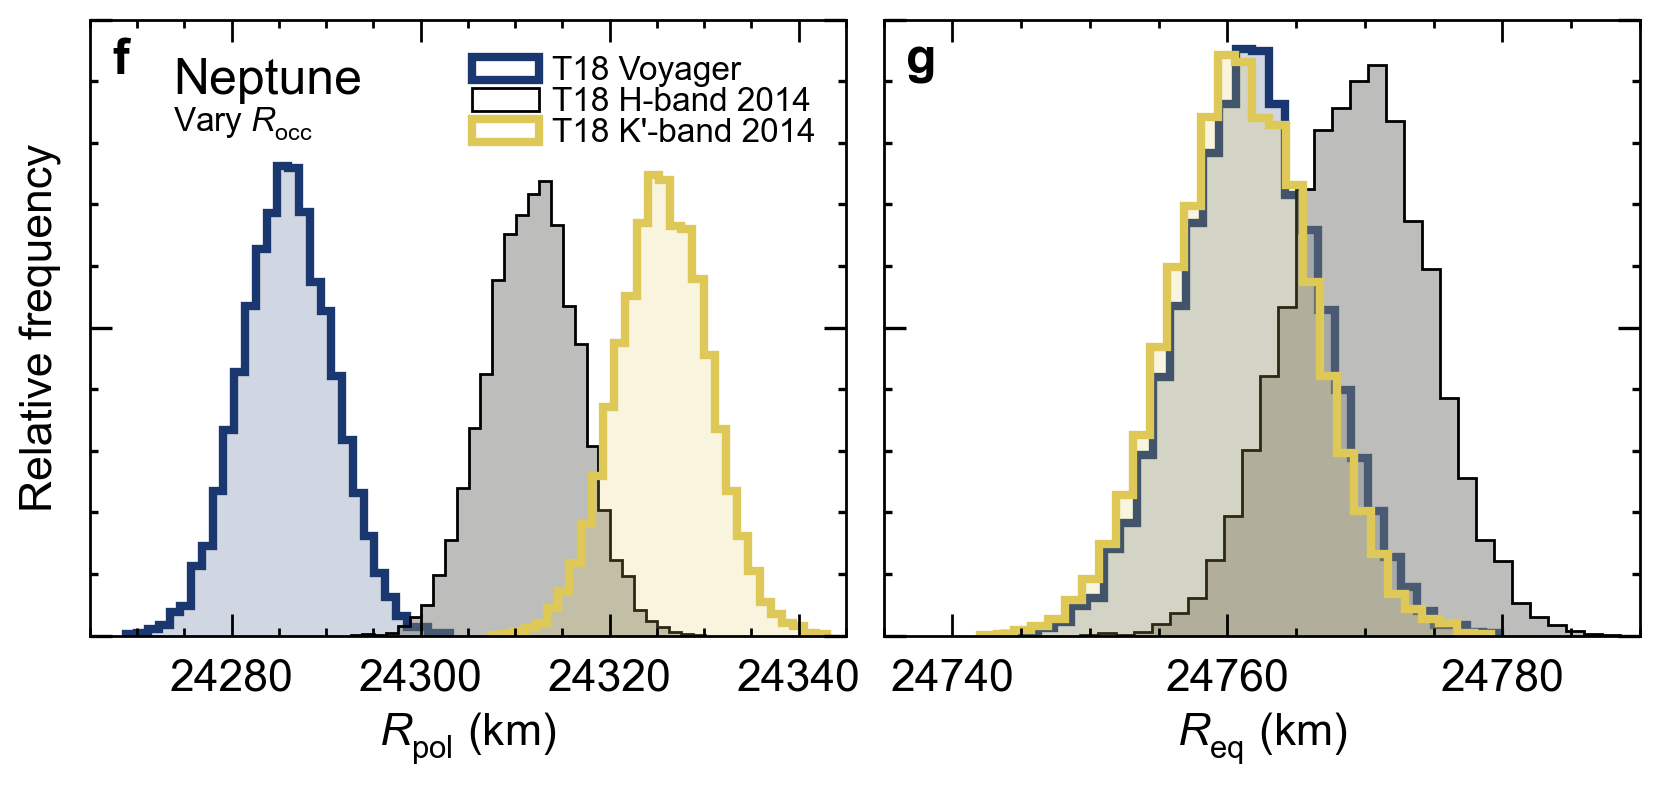

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'wspace':0.05})
for iwind, (wind_option, spec) in enumerate(wind_options.items()):
    color = spec['color']
    rp = np.array([g.r[0] for seed, g in models_vary_ro[wind_option].items()])
    re = np.array([g.r[len(g.mu) // 2] for seed, g in models_vary_ro[wind_option].items()])
    if iwind == 1:
        ax[0].hist(1e-5 * rp, alpha=0.5, histtype='stepfilled', density=True, color=color, bins=30, zorder=0)
        ax[0].hist(1e-5 * rp, histtype='step', density=True, color='k', bins=30, lw=1, label=spec['label'], zorder=0)
        ax[1].hist(1e-5 * re, alpha=0.5, histtype='stepfilled', density=True, color=color, bins=30, zorder=0)
        ax[1].hist(1e-5 * re, histtype='step', density=True, color='k', bins=30, lw=1, label=spec['label'], zorder=0)
    else:
        ax[0].hist(1e-5 * rp, alpha=0.2, histtype='stepfilled', density=True, color=color, bins=30, zorder=0)
        ax[0].hist(1e-5 * rp, histtype='step', density=True, color=color, bins=30, lw=3, label=spec['label'], zorder=0)
        ax[1].hist(1e-5 * re, alpha=0.2, histtype='stepfilled', density=True, color=color, bins=30, zorder=0)
        ax[1].hist(1e-5 * re, histtype='step', density=True, color=color, bins=30, lw=3, label=spec['label'], zorder=0)
    print(rf'{wind_option}: pole: ${np.mean(rp*1e-5):.1f}\pm{np.std(rp*1e-5):.1f}$ km')
    print(rf'{wind_option}: equator: ${np.mean(re*1e-5):.1f}\pm{np.std(re*1e-5):.1f}$ km')

for iax, z in enumerate(ax):
    yl = np.array(z.get_ylim())
    if iax == 0: 
        yl *= 1.25
    z.set_yticks([0, yl[1] / 2, yl[1]], minor=False)
    z.set_yticks(np.linspace(0, yl[1], 11), minor=True)
    z.set_ylim(*yl)

ax[0].legend(fontsize=12, loc=1, bbox_to_anchor=(1, 0.99))

ax[0].set_xlabel(r'$R_{\rm pol}$ (km)')
ax[1].set_xlabel(r'$R_{\rm eq}$ (km)')
ax[0].set_ylabel(r'Relative frequency')
# plt.gca().yaxis.set_ticks([0, yl[1]/2, yl[1]], minor=False)
[z.tick_params(labelleft=False) for z in ax]
# ax[0].set_xlim(23800, 24500)
ax[0].set_xlim(24265, 24345)
ax[1].set_xlim(24735, 24790)
ax[0].text(0.11, 0.88, 'Neptune',                fontsize=18, ha='left', transform=ax[0].transAxes)
ax[0].text(0.11, 0.82, r'Vary $R_{\rm occ}$',    fontsize=12, ha='left', transform=ax[0].transAxes)
for iax, c in enumerate('fg'):
    ax[iax].text(0.03, 0.97, c, weight='bold', fontsize=18, ha='left', va='top', transform=ax[iax].transAxes)

# fig.suptitle(r'Vary $R_{\rm occ}$')
plt.savefig('figures/neptune_radii_vary_ro.pdf')

Text(0, 0.5, '$10^6\\,J_4$')

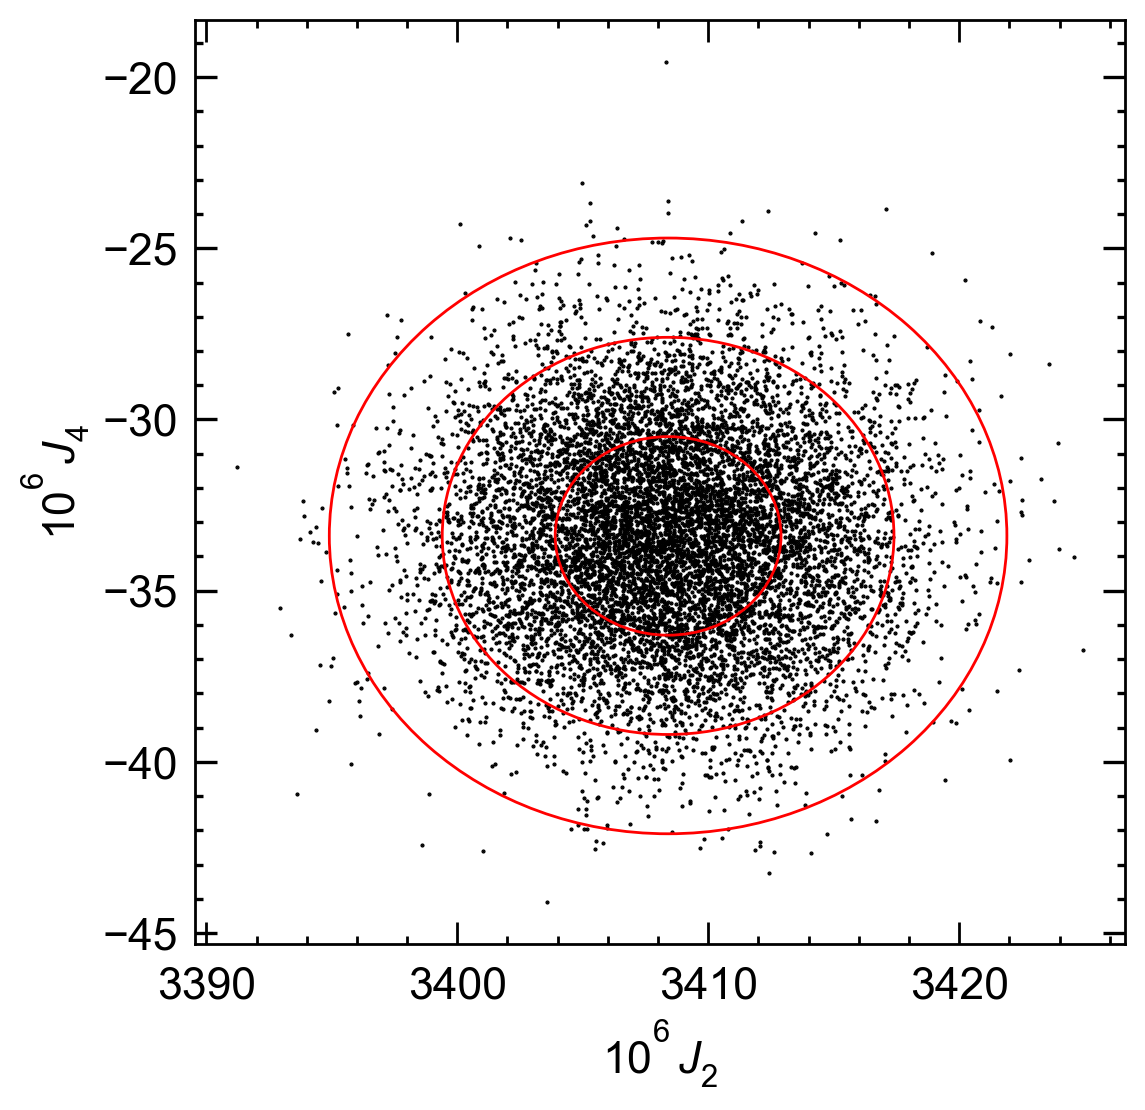

In [13]:
# Jacobson 2009
# J2(×10−6) 3410.5 ± 9.0 3408.428530717952 ± 4.5
# J4(×10−6)−34.7 ± 10.0−33.398917590066 ± 2.9
j2, dj2 = 3408.4e-6, 4.5e-6
j4, dj4 = -33.4e-6, 2.9e-6

from scipy.stats import multivariate_normal
gauss_jn = multivariate_normal(
    mean=np.array([j2, j4]),
    cov=np.array([
        [dj2 ** 2, 0.], 
        [0., dj4 ** 2]
        ])
)

[plt.plot(1e6*pair[0], 1e6*pair[1], 'k.', ms=1) for pair in np.array([gauss_jn.rvs() for i in np.arange(10000)])];




def ellipse(ax, xmean, xscale, ymean, yscale, rho_xy, n_std=3, facecolor='tab:pink', edgecolor='tab:pink', **kwargs):
    from matplotlib.patches import Ellipse
    import matplotlib.transforms as transforms
    cov = np.array([[1., rho_xy], [rho_xy, 1.]])
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse(
        xy=(0, 0), 
        width=ell_radius_x * 2, 
        height=ell_radius_y * 2,
        facecolor=facecolor,
        edgecolor=edgecolor,
        **kwargs
        )

    scale_x = np.sqrt(cov[0, 0]) * xscale * n_std
    scale_y = np.sqrt(cov[1, 1]) * yscale * n_std
    mean_x = xmean
    mean_y = ymean

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

ax = plt.gca()
ellipse(ax, xmean=1e6*j2, xscale=1e6*dj2, ymean=1e6*j4, yscale=1e6*dj4, rho_xy=0., n_std=3, edgecolor='r',  facecolor='none', zorder=2)
ellipse(ax, xmean=1e6*j2, xscale=1e6*dj2, ymean=1e6*j4, yscale=1e6*dj4, rho_xy=0., n_std=2, edgecolor='r',  facecolor='none', zorder=2)
ellipse(ax, xmean=1e6*j2, xscale=1e6*dj2, ymean=1e6*j4, yscale=1e6*dj4, rho_xy=0., n_std=1, edgecolor='r',  facecolor='none', zorder=2)
ax.set_xlabel(r'$10^6\,J_2$')
ax.set_ylabel(r'$10^6\,J_4$')

In [14]:
# finally vary jn
reload(wind_profiles)

latitude, radius = occultation_radii['voyager 2 egress']

def solve_one_vary_jn(wind_option):

    omega = omega_interpolants[wind_option]
    j2, j4 = gauss_jn.rvs()
    jn = j2, j4, 0.

    r_pol = 25000e5
    for i in range(50):
        # g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

        # do the faster split calculation since we are running many models -- factor of 10 faster.
        # for the large spread we get out for Neptune, the ≤ 1 km offset with respect to the full model is not important.
        g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=np.pi*2/(16.11 * 3600), omega=omega)

        # compare to data and adjust r_pol
        error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
        if abs(error_km) < 0.001: break
        r_pol += 1e5 * error_km
    else:
        raise RuntimeError('failed in iterations to fit occultations')

    return g

from tqdm import tqdm
models_vary_jn = {}
nmodels = 10000

# for wind_option, spec in wind_options.items():
#     models_vary_jn[wind_option] = {}
#     for i in tqdm(np.arange(nmodels)):
#         models_vary_jn[wind_option][i] = solve_one_vary_jn(wind_option)

# just do it for a single wind profile
models_vary_jn['voyager'] = {}
for i in tqdm(np.arange(nmodels)):
    models_vary_jn['voyager'][i] = solve_one_vary_jn('voyager')


100%|██████████| 10000/10000 [00:33<00:00, 297.29it/s]


voyager: pole: $24286.0\pm0.2$ km
voyager: equator: $24761.8\pm0.1$ km


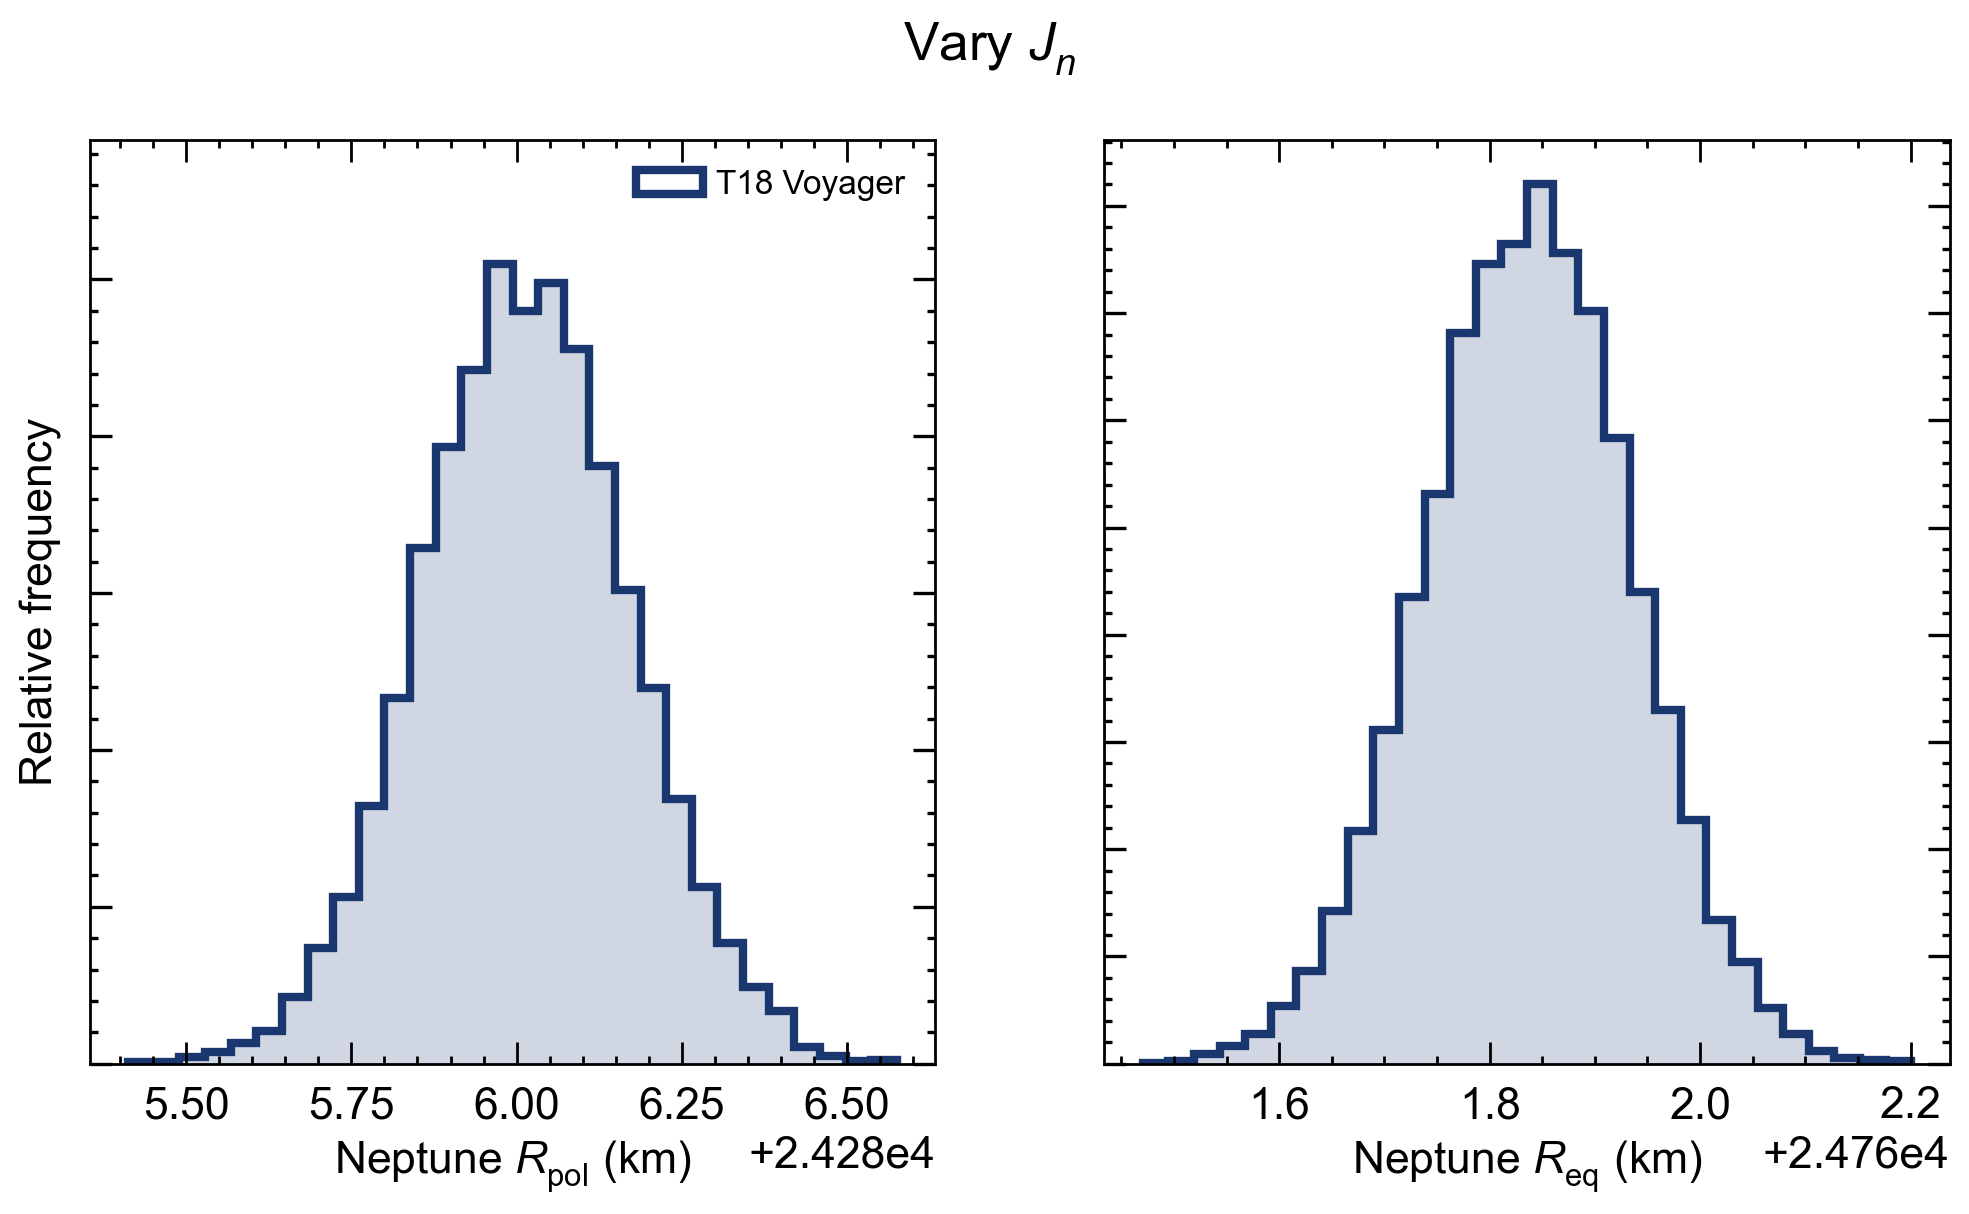

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for iwind, (wind_option, spec) in enumerate(wind_options.items()):
    if wind_option != 'voyager': continue
    color = spec['color']
    rp = np.array([g.r[0] for seed, g in models_vary_jn[wind_option].items()])
    re = np.array([g.r[len(g.mu) // 2] for seed, g in models_vary_jn[wind_option].items()])
    if iwind == 1:
        ax[0].hist(1e-5 * rp, alpha=0.5, histtype='stepfilled', density=True, color=color, bins=30, zorder=0)
        ax[0].hist(1e-5 * rp, histtype='step', density=True, color='k', bins=30, lw=1, label=spec['label'], zorder=0)
        ax[1].hist(1e-5 * re, alpha=0.5, histtype='stepfilled', density=True, color=color, bins=30, zorder=0)
        ax[1].hist(1e-5 * re, histtype='step', density=True, color='k', bins=30, lw=1, label=spec['label'], zorder=0)
    else:
        ax[0].hist(1e-5 * rp, alpha=0.2, histtype='stepfilled', density=True, color=color, bins=30, zorder=0)
        ax[0].hist(1e-5 * rp, histtype='step', density=True, color=color, bins=30, lw=3, label=spec['label'], zorder=0)
        ax[1].hist(1e-5 * re, alpha=0.2, histtype='stepfilled', density=True, color=color, bins=30, zorder=0)
        ax[1].hist(1e-5 * re, histtype='step', density=True, color=color, bins=30, lw=3, label=spec['label'], zorder=0)
    print(rf'{wind_option}: pole: ${np.mean(rp*1e-5):.1f}\pm{np.std(rp*1e-5):.1f}$ km')
    print(rf'{wind_option}: equator: ${np.mean(re*1e-5):.1f}\pm{np.std(re*1e-5):.1f}$ km')

yl = ax[0].get_ylim()
ax[0].set_ylim(yl[0], 1.1*yl[1])
ax[0].legend(fontsize=12)

ax[0].set_xlabel(r'Neptune $R_{\rm pol}$ (km)')
ax[1].set_xlabel(r'Neptune $R_{\rm eq}$ (km)')
ax[0].set_ylabel(r'Relative frequency')
# plt.gca().yaxis.set_ticks([0, yl[1]/2, yl[1]], minor=False)
[z.tick_params(labelleft=False) for z in ax]
# ax[0].set_xlim(23800, 24500)
# ax[0].set_xlim(24730, 24800)
# ax[1].set_xlim(24730, 24800)

fig.suptitle(r'Vary $J_n$')
plt.savefig('figures/neptune_radii_vary_jn.pdf')

In [9]:
import pathlib
pathlib.Path('models/statistical_samples/neptune_vary_wind').mkdir(exist_ok=True, parents=True)
pathlib.Path('models/statistical_samples/neptune_vary_rocc').mkdir(exist_ok=True, parents=True)
pathlib.Path('models/statistical_samples/neptune_vary_jn'  ).mkdir(exist_ok=True, parents=True)

if False: # save all the models as pickled python dictionaries. for the several x10^4 models here this is ~6 GB. not the most interoperable but possibly convenient later.
    neptune_models = {
        'vary_wind' : models_vary_wind,
        'vary_ro'   : models_vary_ro,
        'vary_jn'   : models_vary_jn 
    }
    import dill as pickle
    with open('models/geoid_objects/neptune.pkl', 'wb') as fw:
        pickle.dump(neptune_models, fw)

if True: # save abridged set of full models as pickled python dictionaries holding geoid.geoid objects.
    neptune_models = {
        'vary_wind' : models_vary_wind,
        'vary_ro'   : models_vary_ro,
        'vary_jn'   : models_vary_jn 
    }
    neptune_models_abridged = {}
    for experiment, models_this_experiment in neptune_models.items():
        neptune_models_abridged[experiment] = {}
        for wind_option, models_this_wind in models_this_experiment.items():
            neptune_models_abridged[experiment][wind_option] = {}
            for i in list(models_this_wind):
                if i < 128:
                    neptune_models_abridged[experiment][wind_option][i] = neptune_models[experiment][wind_option][i]

    import dill as pickle
    with open('models/geoid_objects/neptune_abridged.pkl', 'wb') as fw:
        pickle.dump(neptune_models_abridged, fw)

if True: # save arrays of equatorial and polar radii, and ~tens of full models, to plaintext
    
    for wind_option in list(wind_options):
        wind_label = wind_option.replace(' ', '_')

        # radii saved to plaintext
        outfile = f'models/statistical_samples/neptune_radii_{wind_label}_wind_vary_wind.txt'
        index = np.array([i for i, g in models_vary_wind[wind_option].items()])
        rp_km = np.array([1e-5 * g.r[0] for i, g in models_vary_wind[wind_option].items()])
        re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for i, g in models_vary_wind[wind_option].items()])
        header  = "polar and equatorial radii for Neptune's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
        header += f'these models assume the {wind_option} wind profile from Tollefson et al. (2018, Icarus 311).\n'
        header += 'the distribution of models in this file comes from randomly drawing wind fit coefficients from Gaussians with means and standard deviations from Table 1 (polynomial profiles).\n'
        header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
        fmt = ('%5i', '%16.8f', '%16.8f')
        np.savetxt(outfile, np.array([index, rp_km, re_km]).T, fmt=fmt, header=header, comments='')

        outfile = f'models/statistical_samples/neptune_radii_{wind_label}_wind_vary_ro.txt'
        index = np.array([i for i, g in models_vary_ro[wind_option].items()])
        rp_km = np.array([1e-5 * g.r[0] for i, g in models_vary_ro[wind_option].items()])
        re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for i, g in models_vary_ro[wind_option].items()])
        header  = "polar and equatorial radii for Neptune's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
        header += f'these models assume the {wind_option} wind profile from Tollefson et al. (2018, Icarus 311).\n'
        header += 'the distribution of models in this file comes from randomly drawing the occultation radius from a Gaussian with standard deviation equal to 5 km.\n'
        header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
        fmt = ('%5i', '%16.8f', '%16.8f')
        np.savetxt(outfile, np.array([index, rp_km, re_km]).T, fmt=fmt, header=header, comments='')

        if wind_option in models_vary_jn:
            outfile = f'models/statistical_samples/neptune_radii_{wind_label}_wind_vary_jn.txt'
            index = np.array([i for i, g in models_vary_jn[wind_option].items()])
            rp_km = np.array([1e-5 * g.r[0] for i, g in models_vary_jn[wind_option].items()])
            re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for i, g in models_vary_jn[wind_option].items()])
            header  = "polar and equatorial radii for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
            header += f'the models in this file assume the {wind_option} wind profile from Tollefson et al. (2018, Icarus 311).\n'
            header += 'the distribution of models in this file comes from randomly drawing the gravity moments j2,j4 from Gaussians with means and standard deviations from Jacobson 2009.\n'
            header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
            fmt = ('%5i', '%16.8f', '%16.8f')
            np.savetxt(outfile, np.array([index, rp_km, re_km]).T, fmt=fmt, header=header, comments='')

        # save main Neptune shape model for Voyager wind fit
        g = g_baseline
        outfile = 'models/neptune_model_voyager_wind.txt'
        header  = "detailed model output for Neptune's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
        header += 'this model assumes the Voyager wind profile from Tollefson et al. (2018, Icarus 311).\n'
        header += 'mu=sin(phi), phi [radians], and lat_deg [degress] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
        # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
        fmt = '%16.10f'
        names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
        for name in names:
            header += f"{name:>16} "
        data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
        np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

        # detailed model output saved to plaintext for a small number of models
        n_models_each_type = 32
        for i in np.arange(n_models_each_type):
            g = models_vary_wind[wind_option][i]
            outfile = f'models/statistical_samples/neptune_vary_wind/neptune_model_{wind_label}_wind_varywind{i:02}.txt'
            header  = "detailed model output for Neptune's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
            header += f'these models assume the {wind_option} wind profile from Tollefson et al. (2018, Icarus 311).\n'
            header += 'the adopted profiles of the wind speed come from coefficients randomly drawn as Gaussians with means and standard deviations from Table 1 (polynomial profiles).\n'
            header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
            # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
            fmt = '%16.10f'
            names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
            for name in names:
                header += f"{name:>16} "
            data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
            np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

        for i in np.arange(n_models_each_type):
            g = models_vary_ro[wind_option][i]
            outfile = f'models/statistical_samples/neptune_vary_rocc/neptune_model_{wind_label}_wind_varyrocc{i:02}.txt'
            header  = "detailed model output for Neptune's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
            header += f'these models assume the {wind_option} wind profile from Tollefson et al. (2018, Icarus 311).\n'
            header += 'target occultation radius (Voyager 2 egress) was randomly sampled from a Gaussian with a 5 km standard deviation.\n'
            header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
            # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
            fmt = '%16.10f'
            names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
            for name in names:
                header += f"{name:>16} "
            data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
            np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

        if wind_option == 'voyager': # only did the vary-jn sample for voyager wind
            for i in np.arange(n_models_each_type):
                g = models_vary_jn[wind_option][i]
                outfile = f'models/statistical_samples/neptune_vary_jn/neptune_model_{wind_label}_wind_varyjn{i:02}.txt'
                header  = "detailed model output for Neptune's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
                header += f'these models assume the {wind_option} wind profile from Tollefson et al. (2018, Icarus 311).\n'
                header += 'input j2 and j4 were randomly sampled from a univariate Gaussians with uncertainties given by Jacobson 2009.\n'
                header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
                # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
                fmt = '%16.10f'
                names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
                for name in names:
                    header += f"{name:>16} "
                data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
                np.savetxt(outfile, data, fmt=fmt, header=header, comments='')
